# TP2 - Etapa 2 en Google Colab: dataset, preprocesamiento, entrenamiento y comparacion de modelos

Notebook de trabajo de la Etapa 2: analisis del dataset, preprocesamiento, fine-tuning de
ResNet18 (Modelo A, obligatorio), CNN propia (Modelo B, opcional) y estudio comparativo.

El entrenamiento se realiza en Colab para aprovechar la GPU:
**Entorno de ejecucion -> Cambiar tipo de entorno de ejecucion -> GPU (T4)**.

Requisitos previos (en tu fork):
- `train_classifier`, `evaluate_classifier` y `extract_custom_embedding` implementadas
  en `src/lib/services/classifier_service.py` (esta notebook solo las orquesta).

Al finalizar:
- Descargar los checkpoints generados y colocarlos en `models/` de tu entorno local
  (la aplicacion los usa en las pestañas Etapa 1 y 2 del frontend).
- Publicarlos en un link de solo lectura publico para los docentes.
- Entregar esta notebook ejecutada, con sus salidas.

## Equipo
- Alumno 1 : Matías Taborda
- Alumno 2 :

## 1. Clonar el repositorio

Si tu fork es privado, genera un token de acceso (GitHub -> Settings -> Developer settings ->
Personal access tokens) y usalo en la URL, o sube un zip del proyecto a Colab/Drive.

In [3]:
# TO-DO: completar con la URL de tu fork.
# Repo privado: https://<TOKEN>@github.com/<usuario>/tuia-dog-recognition-app.git
REPO_URL = "https://github.com/matitab/tuia-dog-recognition-app.git"

!git clone $REPO_URL proyecto
%cd proyecto

Cloning into 'proyecto'...
remote: Enumerating objects: 157, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 157 (delta 45), reused 27 (delta 27), pack-reused 103 (from 1)
Receiving objects: 100% (157/157), 489.83 KiB | 15.80 MiB/s, done.
Resolving deltas: 100% (86/86), done.
/content/proyecto


## 2. Instalar dependencias

Colab ya incluye torch, torchvision, opencv, numpy, scikit-learn y matplotlib;
solo se instala lo que falta.

In [ ]:
!pip install -q pydantic-settings python-dotenv kagglehub albumentations

## 3. Configuracion del entorno

En Colab no hay PostgreSQL; la Etapa 2 no usa la base vectorial, por lo que se desactiva
pgvector. La configuracion se define por variables de entorno **antes** de importar `lib`.

In [9]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as T
from PIL import Image


os.environ["USE_PGVECTOR"] = "false"
# Ajusta aca cualquier otra variable (IMAGE_SIZE, EMBEDDING_DIM, paths, etc.)

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from lib.config import settings

import torch
print("dataset_path:", settings.dataset_path)
print("GPU disponible:", torch.cuda.is_available())

dataset_path: data/dataset
GPU disponible: True


## 4. Descargar el dataset

In [5]:
!python scripts/download_dataset.py
!ls data/dataset

Descargando gpiosenka/70-dog-breedsimage-data-set ...
Using Colab cache for faster access to the '70-dog-breedsimage-data-set' dataset.
Dataset disponible en /content/proyecto/data/dataset
dogs.csv  test	train  valid


## 5. Analisis del dataset

TO-DO:
- Analizar la distribucion de clases y documentar la cantidad de imagenes por raza.
- Definir los conjuntos de entrenamiento, validacion y prueba.
- Construir un conjunto independiente para evaluacion (ej: imagenes descargadas de internet).
- Filtrar imagenes de baja calidad (documentar el criterio).

split
test      700
train    7946
valid     700
Name: cantidad, dtype: int64

Total razas: 71


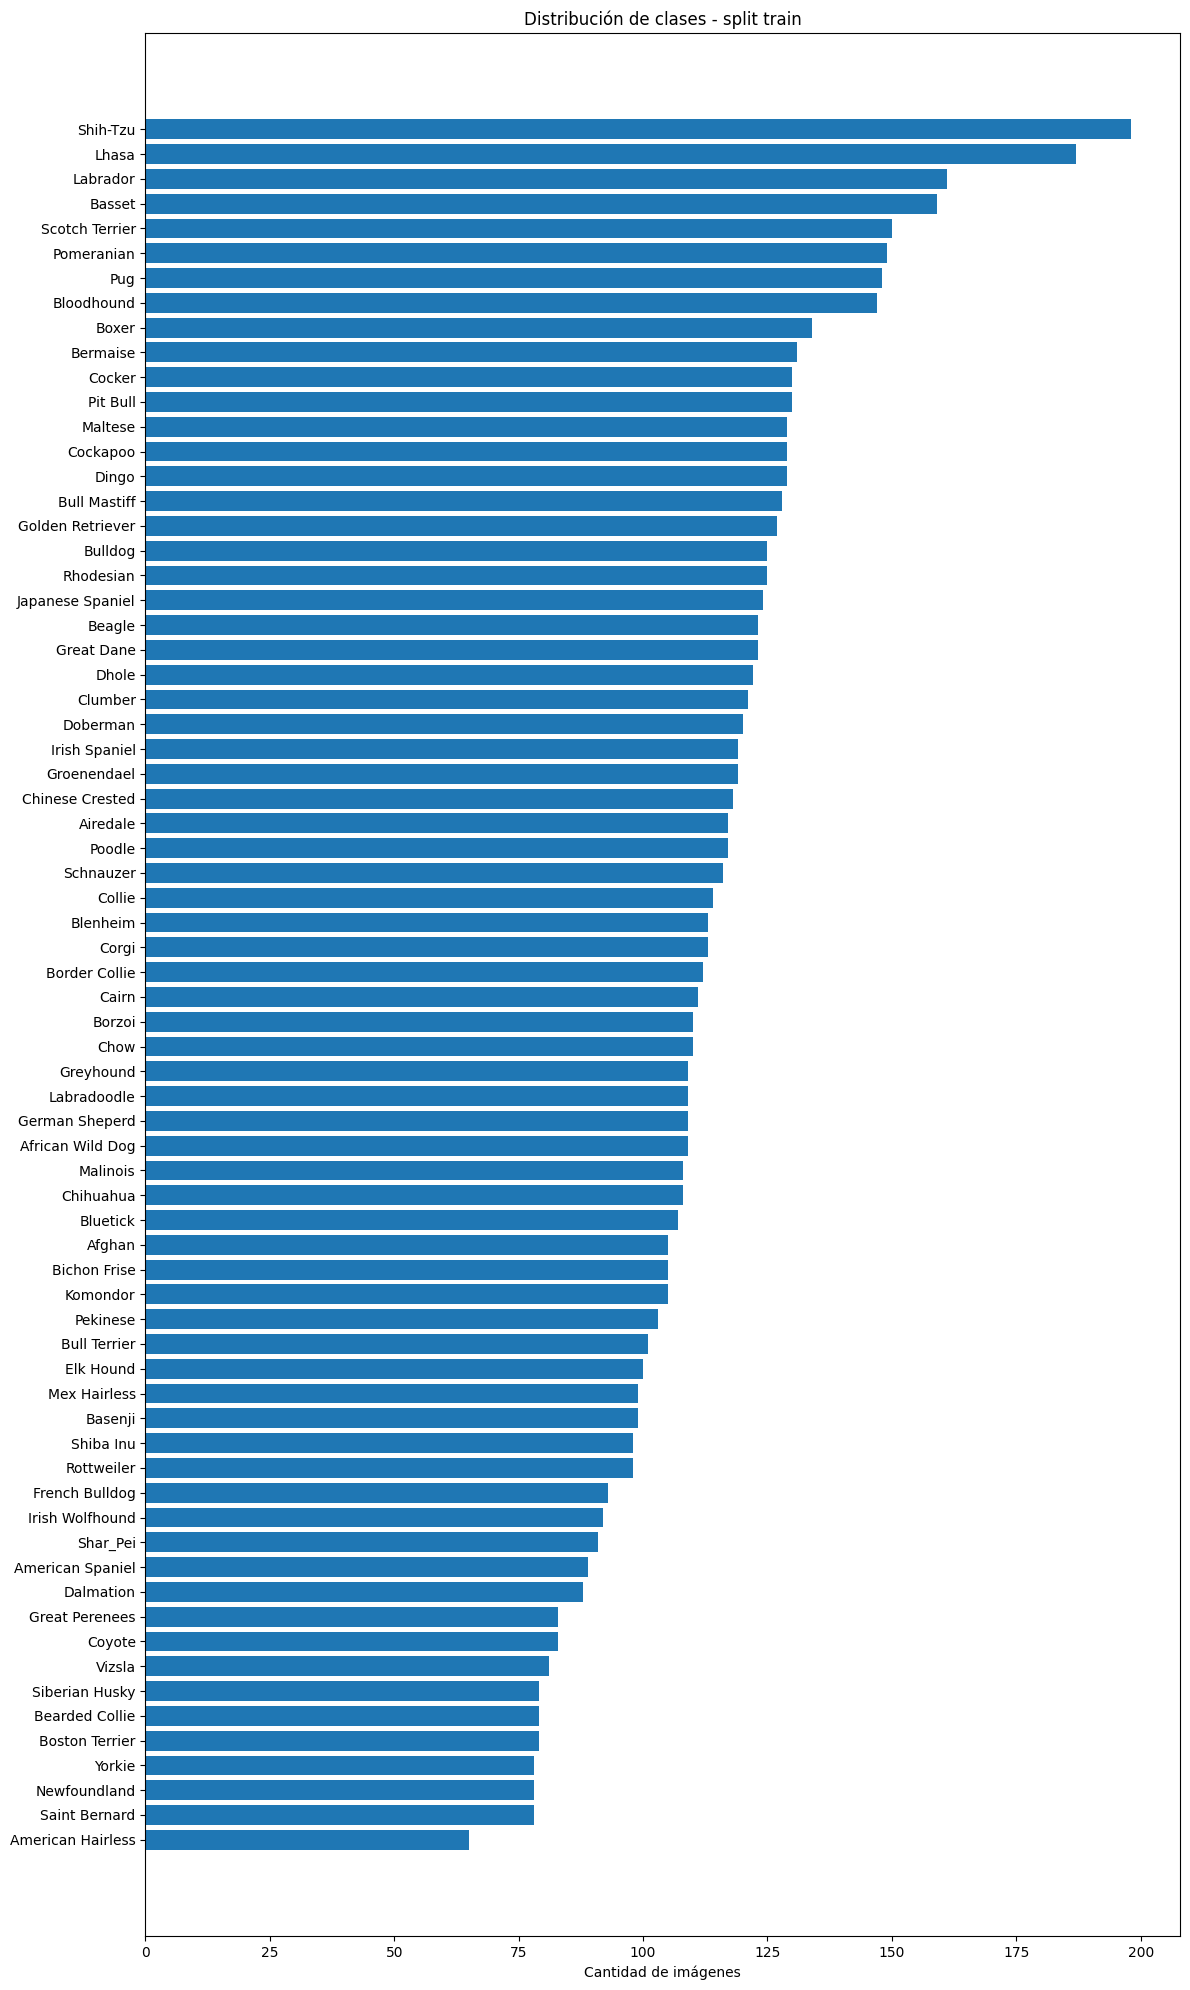

In [8]:
dataset_path = Path("data/dataset")
splits = ["train", "valid", "test"]

# cantidad de imágenes por raza y split
rows = []
for split in splits:
    split_path = dataset_path / split
    for breed_dir in sorted(split_path.iterdir()):
        if breed_dir.is_dir():
            count = len(list(breed_dir.glob("*.jpg")))
            rows.append({"raza": breed_dir.name, "split": split, "cantidad": count})

df = pd.DataFrame(rows)
print(df.groupby("split")["cantidad"].sum())
print(f"\nTotal razas: {df['raza'].nunique()}")

# distribución por raza en train
train_df = df[df["split"] == "train"].sort_values("cantidad")
plt.figure(figsize=(12, 20))
plt.barh(train_df["raza"], train_df["cantidad"])
plt.xlabel("Cantidad de imágenes")
plt.title("Distribución de clases - split train")
plt.tight_layout()
plt.show()

El dataset contiene 71 razas con un total de 9346 imágenes distribuidas en:
- Train: 7946 imágenes
- Valid: 700 imágenes
- Test: 700 imágenes

Las razas tienen entre 78 y 160 imágenes en train.

Se observa que la distribución de clases está desbalanceada, siendo la raza más representada en train Shih-Tzu (con aprox. 198 imágenes) y la que menos aparece es American Hairless (aprox. 65 imágenes).

Los splits valid y test tienen 700 imágenes cada uno, con exactamente 10 imágenes por raza, por lo que están balanceados.

## 6. Preprocesamiento

TO-DO: definir y justificar resize, normalizacion y data augmentation (horizontal flip,
rotacion, blur, variaciones de brillo y contraste, ruido).

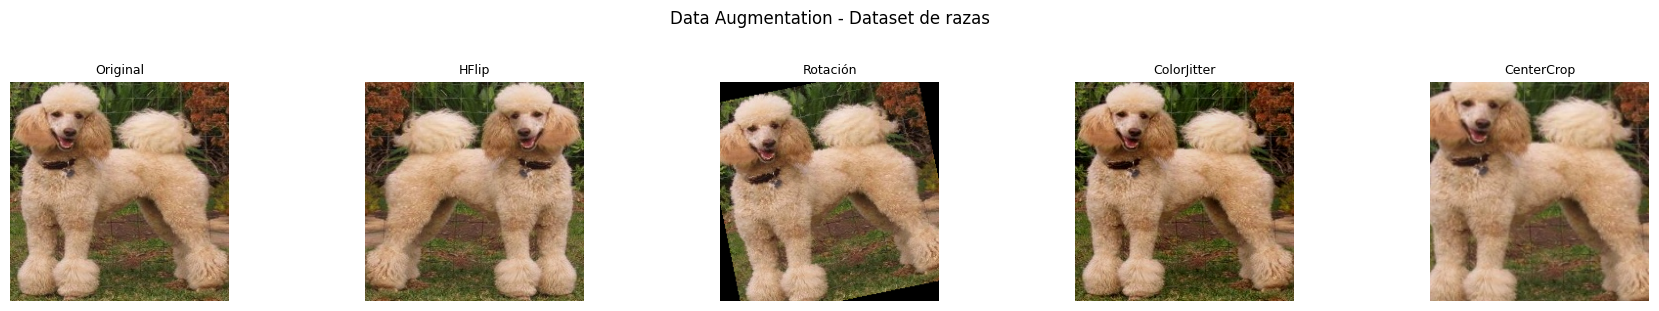

In [11]:
# Elegimos una imagen de ejemplo
sample_path = next((Path("data/dataset/train")).rglob("*.jpg"))
img = Image.open(sample_path).convert("RGB")

# Realizamos las respectivas transformaciones de entrenamiento
tfm_train = T.Compose([
    T.Resize(256),
    T.RandomHorizontalFlip(p=1.0),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Visualiza
augmentaciones = {
    "Original": T.Compose([T.Resize(224), T.ToTensor()]),
    "HFlip": T.Compose([T.Resize(224), T.RandomHorizontalFlip(p=1.0), T.ToTensor()]),
    "Rotación": T.Compose([T.Resize(224), T.RandomRotation(15), T.ToTensor()]),
    "ColorJitter": T.Compose([T.Resize(224), T.ColorJitter(brightness=0.2, contrast=0.2), T.ToTensor()]),
    "CenterCrop": T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor()]),
}

fig, axes = plt.subplots(1, len(augmentaciones), figsize=(18, 3))
for ax, (nombre, tfm) in zip(axes, augmentaciones.items()):
    img_t = tfm(img).permute(1, 2, 0).clamp(0, 1)
    ax.imshow(img_t)
    ax.set_title(nombre, fontsize=9)
    ax.axis("off")
plt.suptitle("Data Augmentation - Dataset de razas", y=1.02)
plt.tight_layout()
plt.show()

Tomemos como ejemplo la imagen de este caniche, en las fotos (de la 2da a la 5ta) se aprecian los efectos de cada transformación:

- Resize(256) + CenterCrop(224): permite preservar la región central de la foto, donde es más probable que esté el perro.
- RandomHorizontalFlip: el caniche mirando a la derecha o izquierda sigue siendo la misma raza, por lo que duplica el dataset.
- RandomRotation(15°): permite simular variaciones de ángulo en las fotos.
- ColorJitter: simula variaciones de iluminación y contraste entre fotos.
- Normalize (media y std de ImageNet): es necesario porque el modelo fue preentrenado con esos valores.

## 7. Modelo A (obligatorio): fine-tuning de ResNet18

`train_classifier` debe guardar el checkpoint en `models/resnet18_finetuned.pth`
(o el nombre configurado en RESNET18_MODEL_NAME). Documentar los hiperparametros
utilizados (learning rate, batch size, epochs, optimizador, scheduler).

In [ ]:
from lib.bootstrap import build_classifier

classifier = build_classifier(settings)
classifier.set_active_model("resnet18_finetuned")
classifier.train_classifier()

In [ ]:
metrics_a = classifier.evaluate_classifier()
metrics_a

### Curvas de entrenamiento y matriz de confusion (Modelo A)

TO-DO: graficar las curvas de entrenamiento/validacion y la matriz de confusion.

In [ ]:
## TO-DO: curvas de entrenamiento y matriz de confusion del Modelo A.

## 8. Modelo B (opcional, recomendado): CNN propia

`train_classifier` con el modelo activo `cnn_custom` debe guardar el checkpoint en
`models/cnn_custom.pth` (o el nombre configurado en CNN_CUSTOM_MODEL_NAME).

In [ ]:
# classifier.set_active_model("cnn_custom")
# classifier.train_classifier()
# metrics_b = classifier.evaluate_classifier()
# metrics_b

## 9. Estudio comparativo

TO-DO (pequeño estudio de la Etapa 2):
- Comparar los modelos entrenados: accuracy, precision, recall, specificity, F1.
- Analizar las clases con peor desempeño (falsos positivos / falsos negativos).
- Discutir trade-offs (performance vs costo computacional).
- Copiar las conclusiones al informe (`informe.ipynb`).

In [ ]:
## TO-DO: comparacion entre modelos y analisis de errores.

## 10. Descargar los checkpoints

Descargalos y colocalos en `models/` de tu entorno local para que la aplicacion los use
(pestañas Etapa 1 y 2 del frontend). Recorda publicarlos en un link de solo lectura publico.

In [ ]:
!ls -lh models/

try:
    from google.colab import files

    files.download(str(settings.model_path / settings.resnet18_model_name))
    # files.download(str(settings.model_path / settings.cnn_custom_model_name))
except ImportError:
    print("Fuera de Colab: los checkpoints quedan en models/")